<a href="https://colab.research.google.com/github/Arifclasper/1/blob/statistic/milestone_3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 3: Frequency Distribution and Data Visualization

---

**Name:** [Your Name Here]

**ID:** [Your Student ID Here]

---

## Part 1: Data Loading and Preparation

In this section, we will load the dataset and import the necessary libraries for our analysis.

Note: Remove the HASHTAG in the next cell to allow installation of the packages required [IF NEEDED]

In [ ]:
#!pip install pandas numpy matplotlib seaborn

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load dataset
df_wine = pd.read_csv('wine_dataset.csv')   # replace with your actual file path
print("Wine dataset size:", df_wine.shape)
print(df_wine.head())
# Display the first few rows of the dataframe to verify it's loaded correctly


Wine dataset size: (6497, 13)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality style  
0      9.4        5   red  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Part 2: Frequency Distribution Table

Here, we will select a column and construct a frequency distribution table.

### Column Selection

**Justification:**

*(Write a brief justification here for why you chose this specific column for frequency analysis. For example: "I chose the 'Age' column because it is a key demographic variable, and understanding its distribution can provide insights into the age demographics of the subjects in this dataset.")*

In [5]:
# Select the column for analysis
column_to_analyze = 'alcohol'   # numeric column chosen # <-- Replace 'column_name' with the name of the column you chose
num_bins = int(np.ceil(1 + 3.322 * np.log(df_wine[column_to_analyze].count())))
# --- Create the frequency distribution table ---
bins = pd.cut(df_wine[column_to_analyze], bins=num_bins)
# If your data is categorical, you can use value_counts()
# If your data is numerical, you may need to create bins (classes)

# Example for numerical data:
# 1. Determine the number of bins (e.g., using Sturges' rule or square-root choice)
# num_bins = int(np.ceil(1 + 3.322 * np.log(df[column_to_analyze].count())))
# 2. Create bins and labels
# bins = pd.cut(df[column_to_analyze], bins=num_bins)

# Step 1: Calculate Frequency (f)
freq_table = pd.DataFrame(bins.value_counts()).reset_index()
freq_table.columns = ['Class Interval', 'Frequency (f)']
freq_table = freq_table.sort_values(by='Class Interval').reset_index(drop=True)

# Step 2: Calculate Relative Frequency (rf)
total_count = freq_table['Frequency (f)'].sum()
freq_table['Relative Frequency (rf)'] = freq_table['Frequency (f)'] / total_count

# Step 3: Calculate Cumulative Frequency (cf)
freq_table['Cumulative Frequency (cf)'] = freq_table['Frequency (f)'].cumsum()
# Step 4: Calculate Relative Cumulative Frequency (rcf)
freq_table['Relative Cumulative Frequency (rcf)'] = freq_table['Relative Frequency (rf)'].cumsum()


# Display the frequency table
print("Frequency Distribution Table for 'alcohol'")
freq_table

Frequency Distribution Table for 'alcohol'


,Class Interval,Frequency (f),Relative Frequency (rf),Cumulative Frequency (cf),Relative Cumulative Frequency (rcf)
0,"(7.993, 8.223]",2,0.000308,2,0.000308
1,"(8.223, 8.445]",5,0.000770,7,0.001077
2,"(8.445, 8.668]",33,0.005079,40,0.006157
3,"(8.668, 8.89]",189,0.029090,229,0.035247
4,"(8.89, 9.113]",478,0.073572,707,0.108819
5,"(9.113, 9.335]",466,0.071725,1173,0.180545
6,"(9.335, 9.558]",706,0.108666,1879,0.289210
7,"(9.558, 9.781]",351,0.054025,2230,0.343235
8,"(9.781, 10.003]",602,0.092658,2832,0.435893
9,"(10.003, 10.226]",345,0.053101,3177,0.488995


## Part 3: Graphical Representation

In this section, we will visualize the data distribution using various charts.

### 3.1 Bar Chart / Histogram

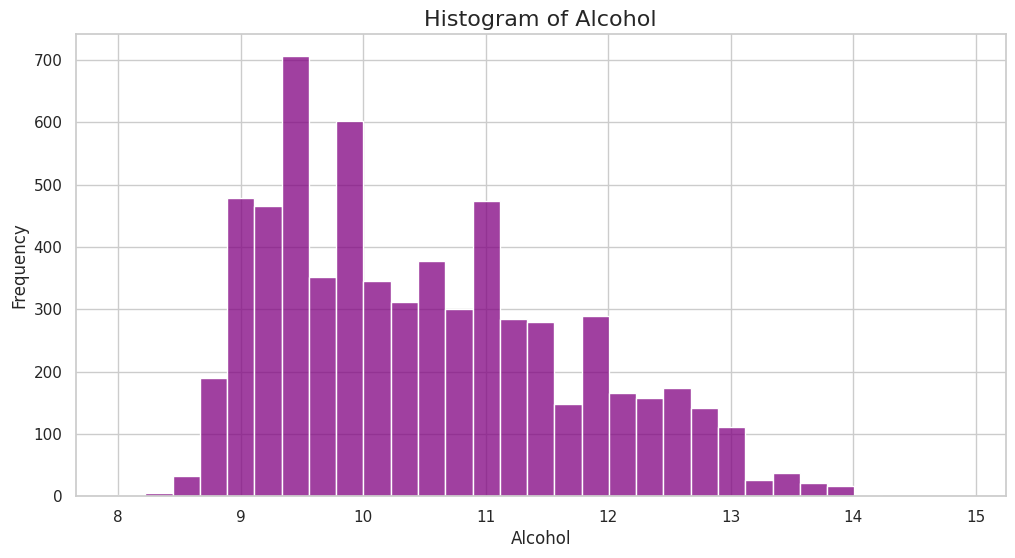

In [6]:
# Create a Bar Chart (for categorical) or a Histogram (for numerical)
plt.figure(figsize=(12,6))
sns.histplot(df_wine[column_to_analyze], bins=num_bins, kde=False, color='purple')
plt.title("Histogram of Alcohol", fontsize=16)
plt.xlabel("Alcohol", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

### 3.2 Line Chart / Frequency Polygon

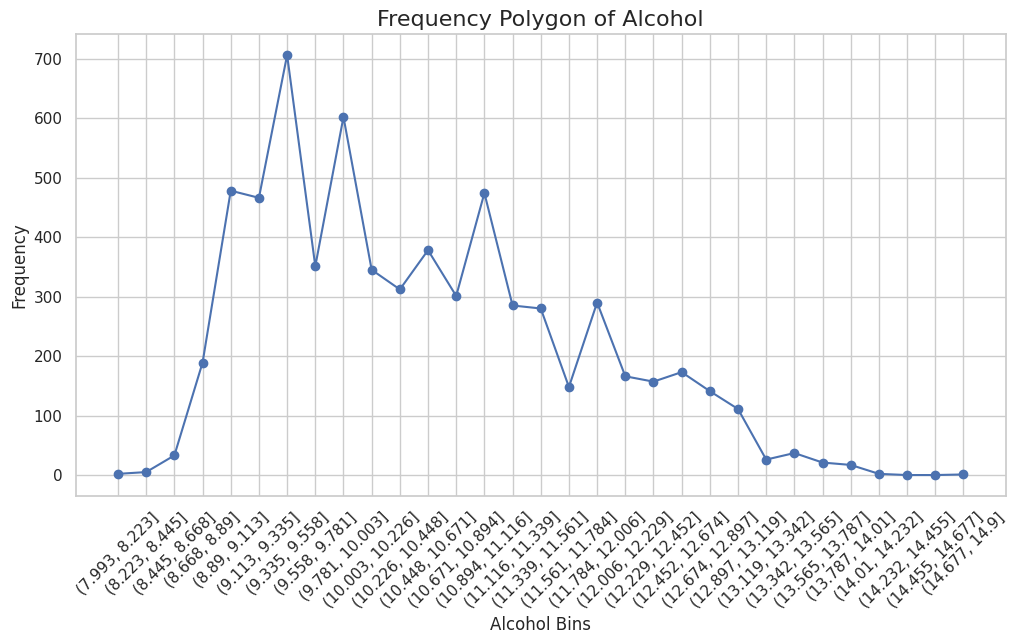

In [7]:
# Create a Line Chart (Frequency Polygon)
plt.figure(figsize=(12,6))
plt.plot(freq_table['Class Interval'].astype(str), freq_table['Frequency (f)'], marker='o', linestyle='-')
plt.title("Frequency Polygon of Alcohol", fontsize=16)
plt.xlabel("Alcohol Bins", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 3.3 Ogive Chart (Cumulative Frequency Graph)

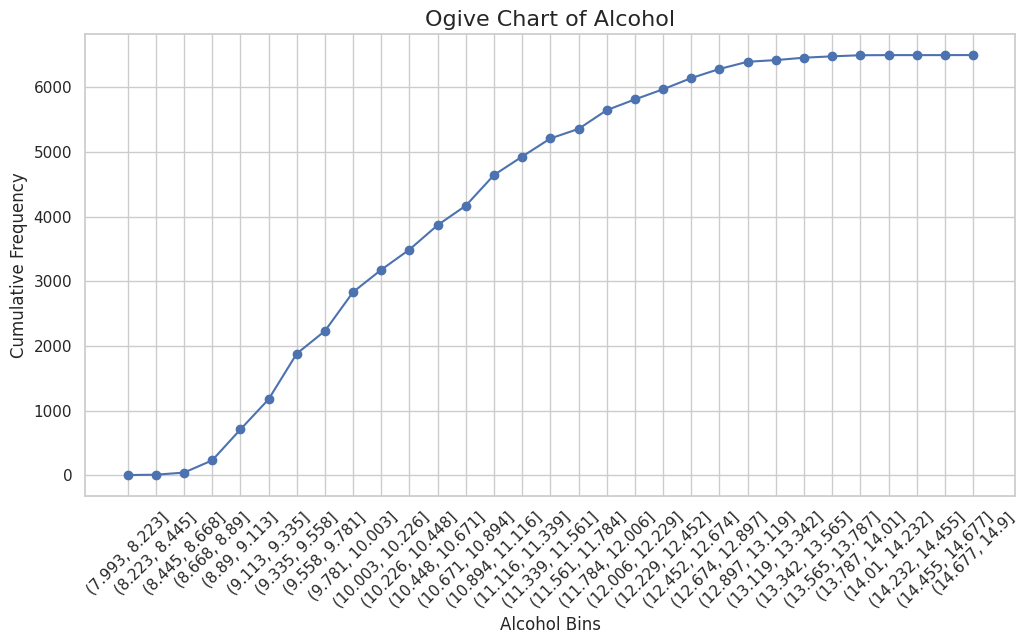

In [8]:
# Create an Ogive Chart
plt.figure(figsize=(12,6))
plt.plot(freq_table['Class Interval'].astype(str), freq_table['Cumulative Frequency (cf)'], marker='o', linestyle='-')
plt.title("Ogive Chart of Alcohol", fontsize=16)
plt.xlabel("Alcohol Bins", fontsize=12)
plt.ylabel("Cumulative Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Part 4: Analysis and Conclusion

---

- Histogram shows alcohol levels are slightly right-skewed, most wines between 9–11%.

- Frequency polygon confirms the peak around mid-range values. #

- Ogive indicates ~50% of wines have alcohol below 10.5%.

## Part 5: Challenges Faced

---

The main challenge was deciding the right number of bins for the histogram. Too few bins oversimplified the data, while too many made the chart noisy. This was solved using Sturges’ rule. Another issue was crowded x‑axis labels in the frequency polygon and ogive, which I fixed by rotating labels and adjusting figure size. Overall, these challenges improved clarity and accuracy in the visualizations.